# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


Global Average Life Expectancy: 67.01


/var/folders/lj/8j5m6ws95ss1gg_hkm6hpbyc0000gn/T/ipykernel_1621/1082703833.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gm_2007['lifeExp_diff'] = gm_2007['lifeExp'] - global_avg


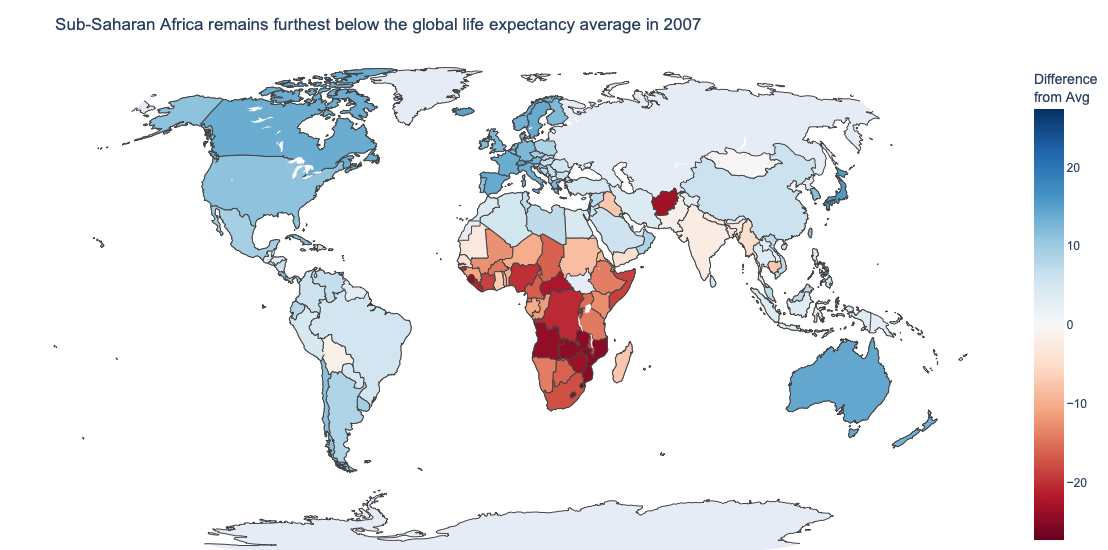

In [2]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json

#dataset
gm = px.data.gapminder()

# Filter for 2007
gm_2007 = gm[gm['year'] == 2007]

#global average life expectancy
global_avg = gm_2007['lifeExp'].mean()

# deviation from average
gm_2007['lifeExp_diff'] = gm_2007['lifeExp'] - global_avg

print("Global Average Life Expectancy:", round(global_avg, 2))

# Create choropleth
fig = px.choropleth(
    gm_2007,
    locationmode='ISO-3',
    locations='iso_alpha',
    color='lifeExp_diff',
    
    # Diverging scale
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'lifeExp_diff': ':.1f',
        'iso_alpha': False
    },
    
    labels={
        'lifeExp_diff': 'Years vs Global Average',
        'lifeExp': 'Life Expectancy'
    },
    
    title='Sub-Saharan Africa remains furthest below the global life expectancy average in 2007',
    
    projection='natural earth',
    height=550
)

fig.update_layout(
    font=dict(family='Arial', size=12),
    geo=dict(showframe=False),
    margin=dict(l=0, r=0, t=60, b=0),
    coloraxis_colorbar=dict(
        title='Difference<br>from Avg'
    )
)

fig.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


{'name': 'Mitte', 'description': '', 'cartodb_id': 1, 'created_at': '2013-09-03T12:32:04+0200', 'updated_at': '2013-09-03T12:32:04+0200'}


/var/folders/lj/8j5m6ws95ss1gg_hkm6hpbyc0000gn/T/ipykernel_1621/1809931189.py:60: DeprecationWarning:

*choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



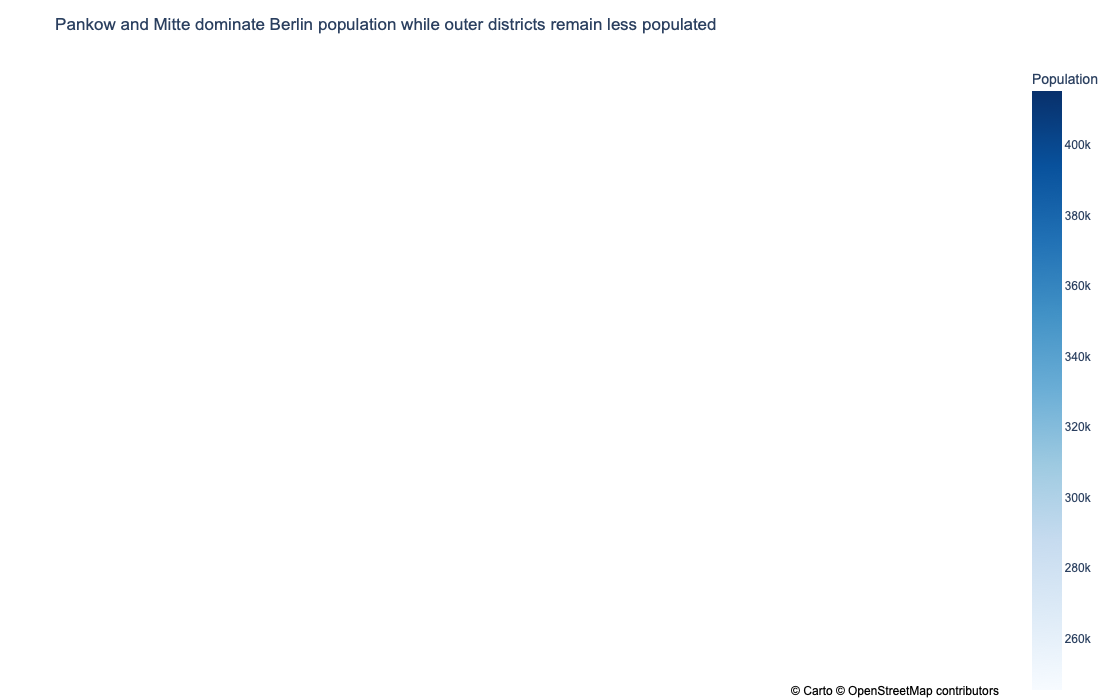

In [3]:
# Task 2
# YOUR CODE HERE

# Load your GeoJSON
# with open('your_file.geojson', 'r') as file:
#     my_geojson = json.load(file)

# Inspect the properties to find the right featureidkey
# print(my_geojson['features'][0]['properties'])
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json
import urllib.request

# Berlin district population data
berlin_pop = pd.DataFrame({
    'district': [
        'Mitte',
        'Friedrichshain-Kreuzberg',
        'Pankow',
        'Charlottenburg-Wilmersdorf',
        'Spandau',
        'Steglitz-Zehlendorf',
        'Tempelhof-Schöneberg',
        'Neukölln',
        'Treptow-Köpenick',
        'Marzahn-Hellersdorf',
        'Lichtenberg',
        'Reinickendorf'
    ],

    'inhabitants': [
        384172,
        295864,
        415221,
        343276,
        245197,
        308706,
        351622,
        335335,
        272843,
        271038,
        295386,
        265755
    ]
})

# GeoJSON URL
url = "https://raw.githubusercontent.com/funkeinteraktiv/Berlin-Geodaten/master/berlin_bezirke.geojson"

# Load GeoJSON
with urllib.request.urlopen(url) as response:
    berlin_geojson = json.load(response)

# Inspect GeoJSON properties
print(berlin_geojson['features'][0]['properties'])

# Create choropleth map
fig = px.choropleth_mapbox(
    data_frame=berlin_pop,
    geojson=berlin_geojson,

    locations='district',
    featureidkey='properties.name',

    color='inhabitants',

    color_continuous_scale='Blues',

    hover_name='district',

    hover_data={
        'district': False,
        'inhabitants': ':,'
    },

    labels={
        'inhabitants': 'Population'
    },

    title='Pankow and Mitte dominate Berlin population while outer districts remain less populated',

    center={'lat': 52.52, 'lon': 13.405},
    zoom=9.5,

    opacity=0.7,
    height=700
)

fig.update_layout(
    font=dict(family='Arial', size=12),

    margin=dict(
        l=0,
        r=0,
        t=60,
        b=0
    ),

    mapbox_style='carto-positron'
)

fig.show()